## Entrenamiento y Evaluación

In [1]:
# librerías de python

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Modelos supervisados
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
import xgboost as xgb
from pathlib import Path


# Métricas
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error, r2_score

# Modelos no supervisados
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA


# Cross validation
from sklearn.model_selection import GridSearchCV

#Importo el mejor modelo
import pickle


In [2]:
# Cargos los datos de los archivos meteorologicos
BASE_DIR = Path().resolve().parent

df = pd.read_csv(BASE_DIR / 'data' / 'processed' / 'meteo_processed.csv')
df.head(3)


,Month,Day,Temperature,Hour,Aerosol Optical Depth,Dew Point,DHI,DNI,GHI,Relative Humidity,Solar Zenith Angle,Pressure,Precipitable Water,Wind Direction,valor
0,1,1,17.2,1,0.078,9.7,0,0,0,61.16,133.50,880,1.5,359,67.21
1,1,1,16.6,2,0.080,9.7,0,0,0,63.85,134.40,879,1.5,353,85.58
2,1,1,16.2,3,0.083,9.7,0,0,0,65.59,130.79,879,1.4,356,82.95


## Modelado

In [3]:
# Prueba con un modelo con 7 variables
''''
# el df con su X, y
X = df.drop(columns=[
    'valor',
    'Aerosol Optical Depth',
    'DNI', #Es colineal con GHI
    'Solar Zenith Angle',
    'Pressure',          # No parece ser relevante
    'Precipitable Water',# No parece ser relevante
])

'''
# el df con su X, y
X = df.drop(columns=['valor'])

# Valor es la variable target que es el precio de la electricidad
y = df['valor'].values

X

,Month,Day,Temperature,Hour,Aerosol Optical Depth,Dew Point,DHI,DNI,GHI,Relative Humidity,Solar Zenith Angle,Pressure,Precipitable Water,Wind Direction
0,1,1,17.2,1,0.078,9.7,0,0,0,61.16,133.50,880,1.5,359
1,1,1,16.6,2,0.080,9.7,0,0,0,63.85,134.40,879,1.5,353
2,1,1,16.2,3,0.083,9.7,0,0,0,65.59,130.79,879,1.4,356
3,1,1,16.0,4,0.083,9.6,0,0,0,65.80,123.52,879,1.4,6
4,1,1,15.9,5,0.081,9.4,0,0,0,65.28,113.79,879,1.4,13
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,7,26,18.4,9,0.037,-12.0,36,599,130,11.60,81.00,881,0.5,77
4996,7,26,18.4,9,0.037,-12.0,36,599,130,11.60,81.00,881,0.5,77
4997,7,26,22.8,10,0.036,-10.0,56,826,353,10.38,68.89,881,0.5,79
4998,7,26,22.8,10,0.036,-10.0,56,826,353,10.38,68.89,881,0.5,79


In [4]:
# Divido en train y en test

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [5]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(4000, 14)
(1000, 14)
(4000,)
(1000,)


In [6]:
#!pip install xgboost

##### Modelos Supervisados  
  
0 Linear Regression  

1 Ridge  

2 Lasso  

3 Random Forest  

4 Gradient Boosting  

5 XGBoost  
    

In [7]:
# Modelos Supervisados
# 1. Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

mae_lr = mean_absolute_error(y_test, y_pred_lr)
mse_lr = mean_squared_error(y_test, y_pred_lr)
rmse_lr = mean_squared_error(y_test, y_pred_lr)**(1/2)
mape_lr = mean_absolute_percentage_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print("mean_absolute_error", mean_absolute_error(y_test, y_pred_lr))
print("mean_squared_error", mean_squared_error(y_test, y_pred_lr))
print("root_mean_squared_error", mean_squared_error(y_test, y_pred_lr)**(1/2))
print("mean_absolute_percentage_error", mean_absolute_percentage_error(y_test, y_pred_lr))
print("R2", r2_score(y_test,y_pred_lr))


mean_absolute_error 18.818698257152267
mean_squared_error 830.6809461167471
root_mean_squared_error 28.821536151231548
mean_absolute_percentage_error 1.7644206157989626e+16
R2 0.6582457313743245


In [8]:
# 2. Ridge
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)
y_pred_ridge = ridge.predict(X_test)

mae_ridge = mean_absolute_error(y_test, y_pred_ridge)
mse_ridge = mean_squared_error(y_test, y_pred_ridge)
rmse_ridge = mse_ridge ** 0.5
mape_ridge = mean_absolute_percentage_error(y_test, y_pred_ridge)
r2_ridge = r2_score(y_test, y_pred_ridge)

print("Ridge")
print("mean_absolute_error", mae_ridge)
print("mean_squared_error", mse_ridge)
print("root_mean_squared_error", rmse_ridge)
print("mean_absolute_percentage_error", mape_ridge)
print("R2", r2_ridge)



Ridge
mean_absolute_error 18.801087456125213
mean_squared_error 830.7140380259243
root_mean_squared_error 28.822110228536776
mean_absolute_percentage_error 1.7596054817404346e+16
R2 0.6582321168797689


In [9]:
# 3. Lasso
lasso = Lasso(alpha=0.1, max_iter=2000)
lasso.fit(X_train, y_train)
y_pred_lasso = lasso.predict(X_test)

mae_lasso = mean_absolute_error(y_test, y_pred_lasso)
mse_lasso = mean_squared_error(y_test, y_pred_lasso)
rmse_lasso = mse_lasso ** 0.5
mape_lasso = mean_absolute_percentage_error(y_test, y_pred_lasso)
r2_lasso = r2_score(y_test, y_pred_lasso)

print("Lasso")
print("mean_absolute_error", mae_lasso)
print("mean_squared_error", mse_lasso)
print("root_mean_squared_error", rmse_lasso)
print("mean_absolute_percentage_error", mape_lasso)
print("R2", r2_lasso)

Lasso
mean_absolute_error 18.746152153051653
mean_squared_error 835.8751477730956
root_mean_squared_error 28.911505456705218
mean_absolute_percentage_error 1.7327397257734856e+16
R2 0.6561087609809887


In [10]:
# 4. Random Forest
rf = RandomForestRegressor(n_estimators=100, max_depth=None, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = mse_rf ** 0.5
mape_rf = mean_absolute_percentage_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("RandomForest")
print("mean_absolute_error", mae_rf)
print("mean_squared_error", mse_rf)
print("root_mean_squared_error", rmse_rf)
print("mean_absolute_percentage_error", mape_rf)
print("R2", r2_rf)

RandomForest
mean_absolute_error 10.223573206616523
mean_squared_error 293.7695904498419
root_mean_squared_error 17.13970800363419
mean_absolute_percentage_error 6496700436710738.0
R2 0.8791389016469149


In [11]:
# 5. Gradient Boosting
gbr = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
gbr.fit(X_train, y_train)
y_pred_gbr = gbr.predict(X_test)

mae_gbr = mean_absolute_error(y_test, y_pred_gbr)
mse_gbr = mean_squared_error(y_test, y_pred_gbr)
rmse_gbr = mse_gbr ** 0.5
mape_gbr = mean_absolute_percentage_error(y_test, y_pred_gbr)
r2_gbr = r2_score(y_test, y_pred_gbr)

print("GradientBoosting")
print("mean_absolute_error", mae_gbr)
print("mean_squared_error", mse_gbr)
print("root_mean_squared_error", rmse_gbr)
print("mean_absolute_percentage_error", mape_gbr)
print("R2", r2_gbr)

GradientBoosting
mean_absolute_error 13.307425055626052
mean_squared_error 479.3953245042721
root_mean_squared_error 21.895098184394424
mean_absolute_percentage_error 8761591088854217.0
R2 0.8027697646437892


In [12]:
# 6. XGBoost
xgb_model = xgb.XGBRegressor(n_estimators=100, max_depth=3, random_state=42, n_jobs=-1)
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)

mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
mse_xgb = mean_squared_error(y_test, y_pred_xgb)
rmse_xgb = mse_xgb ** 0.5
mape_xgb = mean_absolute_percentage_error(y_test, y_pred_xgb)
r2_xgb = r2_score(y_test, y_pred_xgb)

print("XGBoost")
print("mean_absolute_error", mae_xgb)
print("mean_squared_error", mse_xgb)
print("root_mean_squared_error", rmse_xgb)
print("mean_absolute_percentage_error", mape_xgb)
print("R2", r2_xgb)

XGBoost
mean_absolute_error 12.437768668614982
mean_squared_error 410.50154672754906
root_mean_squared_error 20.260837759765735
mean_absolute_percentage_error 8852229187042279.0
R2 0.8311136706247924


In [13]:
results = pd.DataFrame({
    'Model': ['LinearRegression', 'Ridge', 'Lasso', 'RandomForest', 'GradientBoosting', 'XGBoost'],
    'MAE': [mae_lr, mae_ridge, mae_lasso, mae_rf, mae_gbr, mae_xgb],
    'MSE': [mse_lr, mse_ridge, mse_lasso, mse_rf, mse_gbr, mse_xgb],
    'RMSE': [rmse_lr, rmse_ridge, rmse_lasso, rmse_rf, rmse_gbr, rmse_xgb],
    'MAPE': [mape_lr, mape_ridge, mape_lasso, mape_rf, mape_gbr, mape_xgb],
    'R2': [r2_lr, r2_ridge, r2_lasso, r2_rf, r2_gbr, r2_xgb]
})

pd.options.display.float_format = '{:.2f}'.format
results

,Model,MAE,MSE,RMSE,MAPE,R2
0,LinearRegression,18.82,830.68,28.82,17644206157989626.00,0.66
1,Ridge,18.80,830.71,28.82,17596054817404346.00,0.66
2,Lasso,18.75,835.88,28.91,17327397257734856.00,0.66
3,RandomForest,10.22,293.77,17.14,6496700436710738.00,0.88
4,GradientBoosting,13.31,479.40,21.90,8761591088854217.00,0.80
5,XGBoost,12.44,410.50,20.26,8852229187042279.00,0.83


In [14]:
results = pd.DataFrame({
    'Model': ['LinearRegression', 'Ridge', 'Lasso', 'RandomForest', 'GradientBoosting', 'XGBoost'],
    'MAE': [mae_lr, mae_ridge, mae_lasso, mae_rf, mae_gbr, mae_xgb],
    'MSE': [mse_lr, mse_ridge, mse_lasso, mse_rf, mse_gbr, mse_xgb],
    'RMSE': [rmse_lr, rmse_ridge, rmse_lasso, rmse_rf, rmse_gbr, rmse_xgb],
    'R2': [r2_lr, r2_ridge, r2_lasso, r2_rf, r2_gbr, r2_xgb]
})

pd.options.display.float_format = '{:.2f}'.format
results

,Model,MAE,MSE,RMSE,R2
0,LinearRegression,18.82,830.68,28.82,0.66
1,Ridge,18.80,830.71,28.82,0.66
2,Lasso,18.75,835.88,28.91,0.66
3,RandomForest,10.22,293.77,17.14,0.88
4,GradientBoosting,13.31,479.40,21.90,0.80
5,XGBoost,12.44,410.50,20.26,0.83


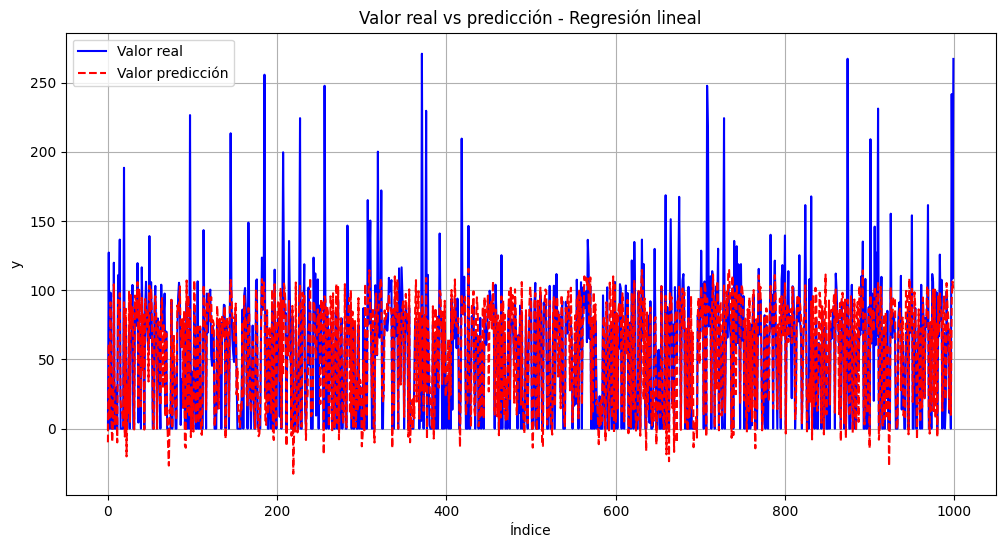

In [15]:
plt.figure(figsize=(12, 6))
plt.plot(range(len(y_test)), y_test, label='Valor real', color='blue')
plt.plot(range(len(y_pred_lr)), y_pred_lr, label='Valor predicción', color='red', linestyle='--')

plt.xlabel('Índice')
plt.ylabel('y')
plt.title('Valor real vs predicción - Regresión lineal')
plt.legend()
plt.grid(True)
plt.show()

In [16]:
# Ajusto hiperparametros

In [17]:
# Defino un pipeline 

pipe = Pipeline(steps=[
    ('scaler', MinMaxScaler()),
    ('regressor', LinearRegression())
])

In [18]:
# Pruebo distintos hiperparametros
param_grid = [
    {
        'regressor': [LinearRegression()]
    },
    {
        'regressor': [Ridge()],
        'regressor__alpha': [0.1, 1.0, 10.0]
    },
    {
        'regressor': [Lasso(max_iter=5000)],
        'regressor__alpha': [0.01, 0.1, 1.0]
    },
    {
        'regressor': [RandomForestRegressor(random_state=42)],
        'regressor__n_estimators': [100, 200],
        'regressor__max_depth': [10, None]
    },
    {
        'regressor': [GradientBoostingRegressor(random_state=42)],
        'regressor__n_estimators': [100, 200],
        'regressor__learning_rate': [0.01, 0.1]
    },
    {
        'regressor': [xgb.XGBRegressor(random_state=42, n_jobs=-1)],
        'regressor__n_estimators': [100, 200],
        'regressor__max_depth': [3, 6],
        'regressor__learning_rate': [0.01, 0.1]
    }
]

In [19]:
from sklearn.model_selection import KFold
cv = KFold(n_splits=5, shuffle=True, random_state=42)

gs = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    cv=cv,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=2,
)

In [20]:
gs.fit(X_train, y_train)

Fitting 5 folds for each of 23 candidates, totalling 115 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...egression())])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","[{'regressor': [LinearRegression()]}, {'regressor': [Ridge()], 'regressor__alpha': [0.1, 1.0, ...]}, ...]"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",KFold(n_split... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computat

In [21]:
print("Mejor modelo:")
print(gs.best_estimator_)

print("\nMejores parámetros:")
print(gs.best_params_)

print("\nMejor score CV:")
print(gs.best_score_)

Mejor modelo:
Pipeline(steps=[('scaler', MinMaxScaler()),
                ('regressor',
                 XGBRegressor(base_score=None, booster=None, callbacks=None,
                              colsample_bylevel=None, colsample_bynode=None,
                              colsample_bytree=None, device=None,
                              early_stopping_rounds=None,
                              enable_categorical=False, eval_metric=None,
                              feature_types=None, feature_weights=None,
                              gamma=None, grow_policy=None,
                              importance_type=None,
                              interaction_constraints=None, learning_rate=0.1,
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
                              max_depth=6, max_leaves=None,
                              min_child_weight=None, missing=nan,
                            

In [22]:
best_model = gs.best_estimator_
y_pred = best_model.predict(X_test)

# R2 del mejor modelo
r2 = r2_score(y_test, y_pred)
r2



0.8800362441217418

In [23]:
print(gs.best_estimator_)

Pipeline(steps=[('scaler', MinMaxScaler()),
                ('regressor',
                 XGBRegressor(base_score=None, booster=None, callbacks=None,
                              colsample_bylevel=None, colsample_bynode=None,
                              colsample_bytree=None, device=None,
                              early_stopping_rounds=None,
                              enable_categorical=False, eval_metric=None,
                              feature_types=None, feature_weights=None,
                              gamma=None, grow_policy=None,
                              importance_type=None,
                              interaction_constraints=None, learning_rate=0.1,
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
                              max_depth=6, max_leaves=None,
                              min_child_weight=None, missing=nan,
                              monotone_con

R² = 0.8998 es bastante bueno, significa que el modelo explica aproximadamente el 90% de la variabilidad de la variable objetivo, así que el ajuste es fuerte.

In [24]:
##### Modelo supervisado, KMEANS

In [25]:
# Voy a escalar los datos antes de usar KMeans
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

k = 3
kmeans = KMeans(n_clusters=k, random_state=101, n_init=10)
y_pred_km = kmeans.fit_predict(X_scaled)

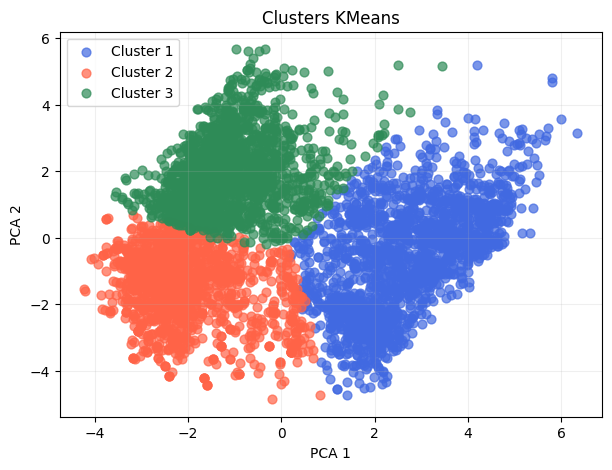

In [26]:
# Para poder observar en 2D voy a aplicar una PCA 
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Gráfico
plt.figure(figsize=(7, 5))

colors = ['royalblue', 'tomato', 'seagreen', 'gold', 'purple', 'orange']

for i in range(k):
    plt.scatter(
        X_pca[y_pred_km == i, 0],
        X_pca[y_pred_km == i, 1],
        s=40,
        color=colors[i % len(colors)],
        label=f'Cluster {i+1}',
        alpha=0.7
    )

plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.title('Clusters KMeans')
plt.legend()
plt.grid(alpha=0.2)
plt.show()

In [27]:
# Resumen por cluster con 
df['cluster'] = y_pred_km

vars_clave = ['Temperature', 'Hour', 'DHI', 'DNI', 'GHI', 'Relative Humidity',
              'Solar Zenith Angle', 'Pressure', 'valor']

resumen_clusters = (
    df.groupby('cluster')[vars_clave]
      .mean()
      .round(2)
      .reset_index()
)

resumen_clusters['cluster'] = 'Cluster ' + (resumen_clusters['cluster'] + 1).astype(str)

display(resumen_clusters)

,cluster,Temperature,Hour,DHI,DNI,GHI,Relative Humidity,Solar Zenith Angle,Pressure,valor
0,Cluster 1,26.80,14.03,120.27,835.90,686.76,25.52,46.33,877.94,8.10
1,Cluster 2,15.40,11.49,9.69,105.96,35.00,34.52,121.37,878.99,78.02
2,Cluster 3,18.49,11.61,8.68,41.35,16.30,59.72,118.99,878.40,86.42


In [28]:
from sklearn.metrics import silhouette_score

In [29]:
results = []

for k in range(2, 11):
    km = KMeans(n_clusters=k, random_state=101, n_init=10)
    labels = km.fit_predict(X_scaled)

    results.append({
        "k": k,
        "inertia": km.inertia_,
        "silhouette": silhouette_score(X_scaled, labels),
    })

results

[{'k': 2, 'inertia': 47972.292472814595, 'silhouette': 0.29849926072895017},
 {'k': 3, 'inertia': 38324.352045243424, 'silhouette': 0.2662253425576542},
 {'k': 4, 'inertia': 33204.68826209967, 'silhouette': 0.24190913746151055},
 {'k': 5, 'inertia': 30253.30059144239, 'silhouette': 0.23260923315309065},
 {'k': 6, 'inertia': 28338.98911664115, 'silhouette': 0.2219489539122025},
 {'k': 7, 'inertia': 26689.57576305503, 'silhouette': 0.2248182564252118},
 {'k': 8, 'inertia': 25171.091658718044, 'silhouette': 0.21771786551012515},
 {'k': 9, 'inertia': 24149.613280662234, 'silhouette': 0.20947484733283395},
 {'k': 10, 'inertia': 23216.576619527244, 'silhouette': 0.21490374479068913}]

In [30]:
# Si uso 10 clusters por ejemplo:

kmeans = KMeans(n_clusters=k, random_state=101, n_init=10)
y_pred_km = kmeans.fit_predict(X_scaled)

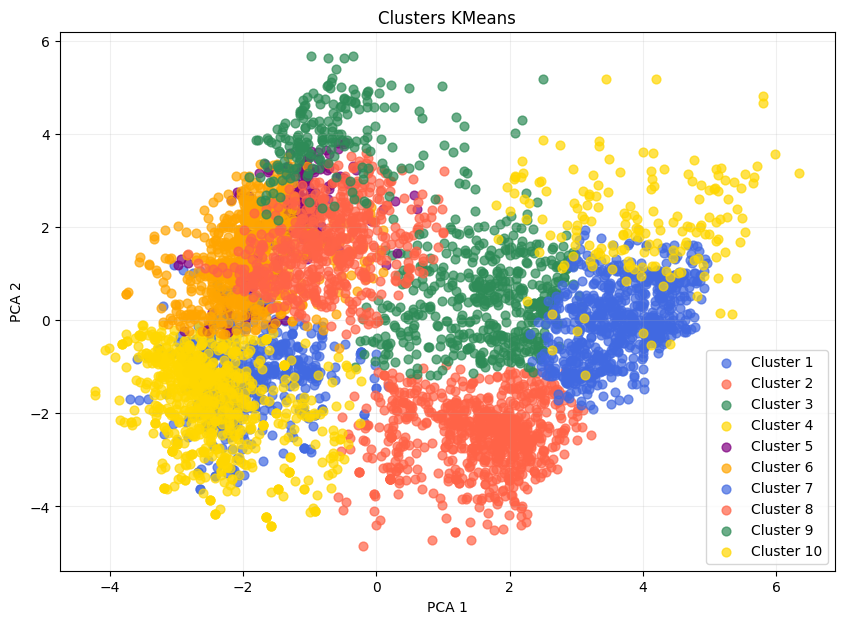

In [31]:
# Para poder observar en 2D voy a aplicar una PCA 
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Gráfico
plt.figure(figsize=(10, 7))

colors = ['royalblue', 'tomato', 'seagreen', 'gold', 'purple', 'orange']

for i in range(k):
    plt.scatter(
        X_pca[y_pred_km == i, 0],
        X_pca[y_pred_km == i, 1],
        s=40,
        color=colors[i % len(colors)],
        label=f'Cluster {i+1}',
        alpha=0.7
    )

plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.title('Clusters KMeans')
plt.legend()
plt.grid(alpha=0.2)
plt.show()

Para elegir k, normalmente busco un un codo claro en la inercia, una silhouette razonablemente alta,
y que los clusters tengan sentido para el problema real.

En k = 2 y k = 3 se ve un codo importante, pero voy a elegir k=3.
Con k = 2: silhouette 0.377, la mejor de todas. 
Con k = 3: silhouette 0.319, sigue siendo aceptable, pero peor que 2, y desde ahí sólo sigue cayendo. 


In [32]:
# Resumen por cluster con 
df['cluster'] = y_pred_km

vars_clave = ['Temperature', 'Hour', 'DHI', 'DNI', 'GHI', 'Relative Humidity',
              'Solar Zenith Angle', 'Pressure', 'valor']

resumen_clusters = (
    df.groupby('cluster')[vars_clave]
      .mean()
      .round(2)
      .reset_index()
)

resumen_clusters['cluster'] = 'Cluster ' + (resumen_clusters['cluster'] + 1).astype(str)

display(resumen_clusters)

,cluster,Temperature,Hour,DHI,DNI,GHI,Relative Humidity,Solar Zenith Angle,Pressure,valor
0,Cluster 1,15.58,21.51,2.79,19.65,4.74,39.71,122.66,879.11,101.36
1,Cluster 2,24.22,13.83,77.67,862.79,557.14,18.30,56.72,878.81,18.79
2,Cluster 3,24.37,13.90,94.90,665.07,385.00,35.55,65.27,878.14,16.69
3,Cluster 4,14.31,5.31,7.48,66.53,18.15,31.35,127.92,878.96,67.76
4,Cluster 5,16.72,3.40,2.03,8.87,3.33,66.39,138.32,878.32,86.74
5,Cluster 6,17.00,4.69,3.65,24.52,6.82,59.67,125.24,878.33,87.62
6,Cluster 7,29.38,14.26,130.29,924.78,894.79,25.12,32.27,877.20,0.51
7,Cluster 8,19.70,21.75,4.16,25.62,6.20,54.37,113.79,878.51,90.65
8,Cluster 9,19.30,7.83,15.07,34.69,22.75,67.14,112.48,878.24,85.36
9,Cluster 10,27.73,13.42,262.67,596.27,729.50,35.72,37.64,877.70,1.94


#### IMPORTO EL MEJOR MODELO

In [33]:
import pickle

In [34]:
final_model=best_model

In [35]:
pickle.dump(final_model, open('final_model.pkl', 'wb'))

In [36]:
# Para importar el modelo
modelo_importado = pickle.load(open("final_model.pkl", 'rb'))
modelo_importado

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"feature_range feature_range: tuple (min, max), default=(0, 1)Desired range of transformed data.","(0, ...)"
,"copy copy: bool, default=TrueSet to False to perform inplace row normalization and avoid acopy (if the input is already a numpy array).",True
,"clip clip: bool, default=FalseSet to True to clip transformed values of held-out data toprovided `feature_range`.Since this parameter will clip values, `inverse_transform` may notbe able to restore the original data... note:: Setting `clip=True` does not prevent feature drift (a distribution shift between training and test data). The transformed values are clipped to the `feature_range`, which helps avoid unintended behavior in models sensitive to out-of-range inputs (e.g. linear models). Use with care, as clipping can distort the distribution of test data... versionadded:: 0.24",False
,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None


In [37]:
modelo_importado.predict(X_test)

array([-3.81060243e-01,  1.16630928e+02,  1.84182811e+00,  1.04058258e+02,
        3.39530781e-02,  1.64937150e+00,  2.71717501e+00,  1.15065163e+02,
        4.07914445e-02,  1.99836004e+00,  1.13220844e+01, -8.62436652e-01,
        1.09825981e+02,  8.33790359e+01,  1.23311478e+02,  9.20774651e+00,
        2.98042035e+00,  1.91375923e+01, -1.10179931e-02,  1.96418518e+02,
       -1.06061414e-01,  9.64828568e+01,  2.19387174e+00,  2.64676476e+00,
        3.02372360e+01,  9.66568604e+01,  9.88652706e+00,  6.97756805e+01,
        6.89649963e+01,  8.68856354e+01,  1.75964108e+01,  9.81746316e-01,
        9.52848129e+01,  7.48870468e+01,  8.23309174e+01,  9.64686356e+01,
        7.29979658e+00,  9.69648819e+01,  2.64749775e+01, -2.17726064e+00,
        1.08688553e+02,  1.06628426e+02,  8.02406006e+01, -7.41918743e-01,
        9.70712128e+01,  9.38484421e+01,  6.78120041e+01,  5.89246559e+01,
        7.41922684e+01,  1.40640839e+02,  6.40118256e+01,  9.01011276e+01,
        7.88088684e+01,  

In [38]:
# Regresión lineal con menos variables
df.head(5)


,Month,Day,Temperature,Hour,Aerosol Optical Depth,Dew Point,DHI,DNI,GHI,Relative Humidity,Solar Zenith Angle,Pressure,Precipitable Water,Wind Direction,valor,cluster
0,1,1,17.20,1,0.08,9.70,0,0,0,61.16,133.50,880,1.50,359,67.21,4
1,1,1,16.60,2,0.08,9.70,0,0,0,63.85,134.40,879,1.50,353,85.58,4
2,1,1,16.20,3,0.08,9.70,0,0,0,65.59,130.79,879,1.40,356,82.95,4
3,1,1,16.00,4,0.08,9.60,0,0,0,65.80,123.52,879,1.40,6,77.55,5
4,1,1,15.90,5,0.08,9.40,0,0,0,65.28,113.79,879,1.40,13,74.87,5


In [39]:
#Pruebo modelo con un punto nuevo

X_nuevo = pd.DataFrame([{
    'Month': 1,
    'Day': 1,
    'Temperature': 17.20,
    'Hour': 1,
    'Aerosol Optical Depth': 0.08,
    'Dew Point': 9.70,
    'DHI': 0,
    'DNI': 0,
    'GHI': 0,
    'Relative Humidity': 61.16,
    'Solar Zenith Angle': 133.50,
    'Pressure': 880,
    'Precipitable Water': 1.50,
    'Wind Direction': 359
}])

modelo_importado.predict(X_nuevo)

array([67.189804], dtype=float32)

In [40]:
#Pruebo modelo con otro punto nuevo
X_nuevo = pd.DataFrame([{
    'Month': 1,
    'Day': 1,
    'Temperature': 16.60,
    'Hour': 2,
    'Aerosol Optical Depth': 0.08,
    'Dew Point': 9.70,
    'DHI': 0,
    'DNI': 0,
    'GHI': 0,
    'Relative Humidity': 63.85,
    'Solar Zenith Angle': 134.40,
    'Pressure': 879,
    'Precipitable Water': 1.50,
    'Wind Direction': 353
}])

X_nuevo
modelo_importado.predict(X_nuevo)

array([78.523094], dtype=float32)

In [41]:
# Pedido Termophoton

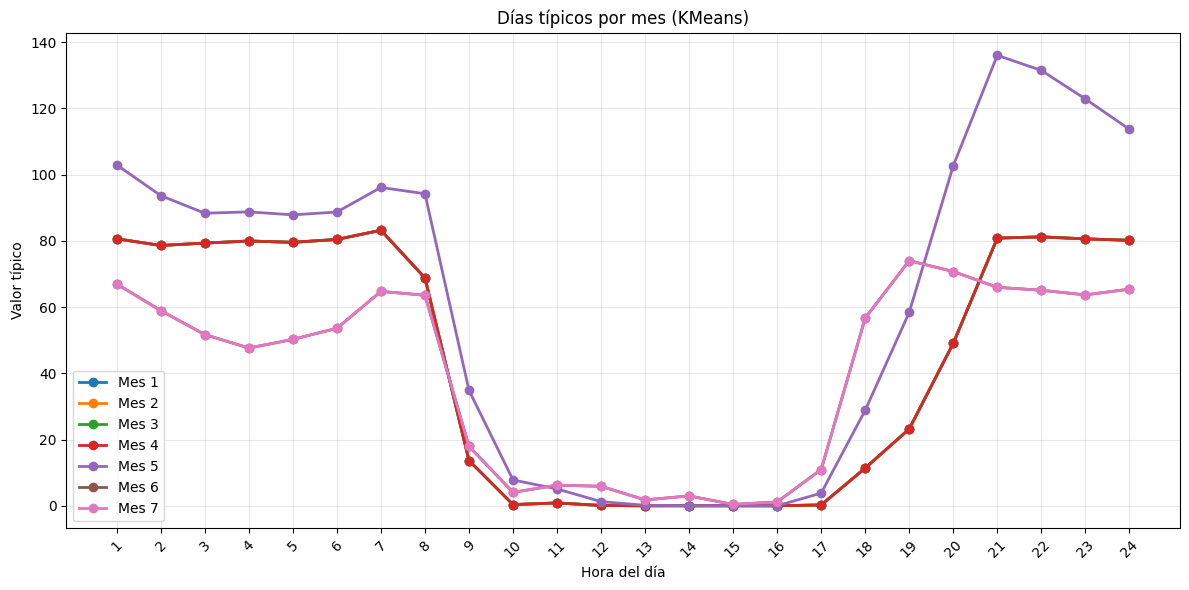

In [42]:
# Creamos una columna con fecha y ordeno los datos
# Combinamos mes, día y año fijo para construir una fecha real
df['date'] = pd.to_datetime({
    'year': 2024,
    'month': df['Month'],
    'day': df['Day']
})

# Obligamos hora a formato número y elimino filas inválidas
df['Hour'] = pd.to_numeric(df['Hour'], errors='coerce')
df = df.dropna(subset=['Hour']).astype({'Hour': int}).sort_values(['date', 'Hour'])

# Promediamos por día y hora en caso de duplicados, luego reorganizamos en matriz (días x horas)
daily = (df.groupby(['date', 'Hour'])['valor']
           .mean()                        # Promedio si hay horas repetidas
           .unstack(level='Hour')         # Filas=días, Columnas=horas
           .fillna(0)                     # Rellenamos huecos con 0
           .sort_index(axis=1))           # Ordenamos columnas por hora (1-24)



# Escalamos para que ninguna hora pese más que otra
scaler = StandardScaler()
X_scaled = scaler.fit_transform(daily.values)

# Encontramos 7 patrones de comportamiento diario
kmeans = KMeans(n_clusters=7, random_state=42, n_init=10)
daily['cluster'] = kmeans.fit_predict(X_scaled)


# Extraemos el mes de cada día y buscamos el cluster más frecuente (moda)
daily['mes'] = daily.index.month
mes_cluster = (daily.groupby('mes')['cluster']
                    .agg(lambda x: x.mode()[0])  # Moda: cluster más repetido en ese mes
                    .to_dict())

#Visualización
horas = [c for c in daily.columns if c not in ['cluster', 'mes']]
plt.figure(figsize=(12, 6))

for mes, clus in mes_cluster.items():
    # Perfil promedio de todos los días que pertenecen al cluster dominante del mes
    perfil = daily[daily['cluster'] == clus][horas].mean().values
    plt.plot(horas, perfil, label=f'Mes {mes}', marker='o', linewidth=2)

plt.xlabel('Hora del día')
plt.ylabel('Valor típico')
plt.title('Días típicos por mes (KMeans)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(horas, rotation=45)
plt.tight_layout()
plt.show()

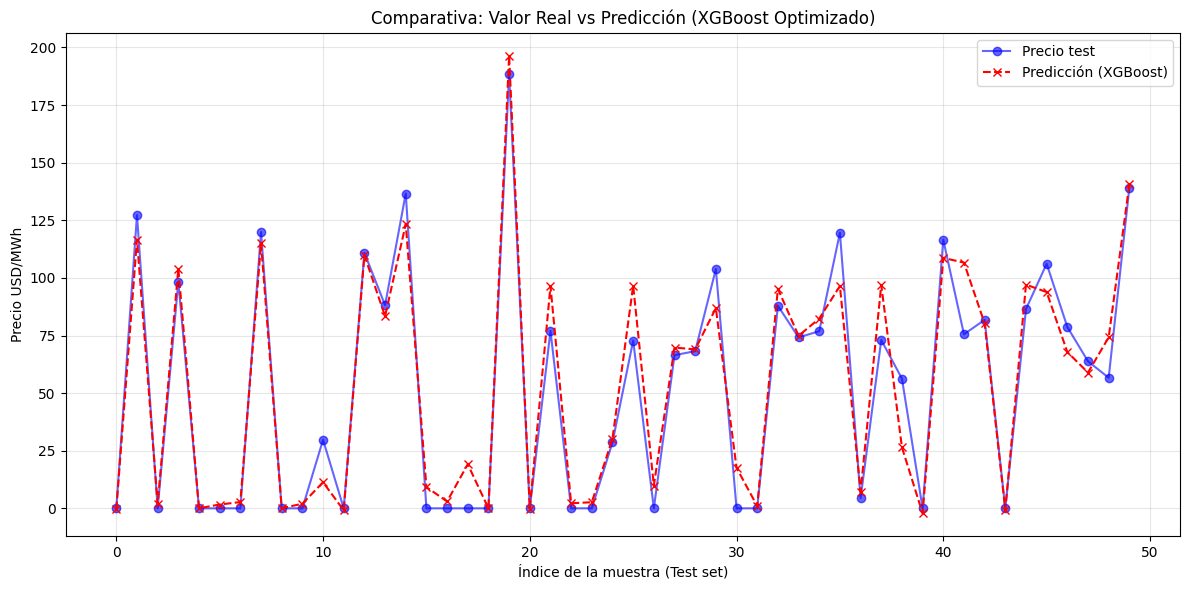

In [43]:
# GRÁFICO DE RESULTADOS DEL MEJOR MODELO

# 1. Predicciones con el mejor modelo
best_model = gs.best_estimator_
y_pred = best_model.predict(X_test)


plt.figure(figsize=(12, 6))

# Dibujo los primeros 50 puntos para que se vea claro el detalle
n_puntos = 50
plt.plot(range(n_puntos), y_test[:n_puntos], label='Precio test', marker='o', color='blue', alpha=0.6)
plt.plot(range(n_puntos), y_pred[:n_puntos], label='Predicción (XGBoost)', marker='x', color='red', linestyle='--')


plt.title('Comparativa: Valor Real vs Predicción (XGBoost Optimizado)')
plt.xlabel('Índice de la muestra (Test set)')
plt.ylabel('Precio USD/MWh')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()